In [109]:
import sys,copy,os,inspect
if hasattr(sys.modules[__name__], '__file__'):
    _file_name = __file__
else:
    _file_name = inspect.getfile(inspect.currentframe())
CURRENT_FILE_PATH = os.path.dirname(_file_name)
sys.path.append(os.getcwd()+"/../neuronVis")
import numpy as np
import matplotlib.pyplot as plt
import IONData
import Visual as nv
import BrainRegion
from tqdm.notebook import tqdm as tool_bar
from distinctipy import distinctipy
from io import StringIO
from distinctipy import distinctipy
from sklearn.cluster import AgglomerativeClustering
import seaborn
%matplotlib inline

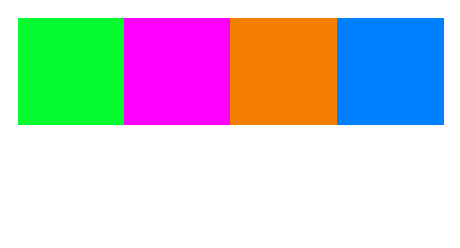

In [148]:
#auxilary functions
iondata = IONData.IONData()
def cluster_visualization(IDs,X,clusters,sampling=0,specific_cluster=-1,colors=[],name='cx'):
    clustering = AgglomerativeClustering(clusters).fit(X)
    if len(colors)==0:
        background_color1 = [0.0,0.0,0.0]
        background_color2 = [1.0,1.0,1.0]
        colors = distinctipy.get_colors(clusters,[background_color1,background_color2])
        distinctipy.color_swatch(colors)
    neuronvis = nv.neuronVis()
    for i,j in zip(IDs,clustering.labels_):
        if specific_cluster!=-1:
            if j!=specific_cluster:
                continue
        if np.random.rand()<sampling:
            continue
        neuronvis.addNeuronByID(i[0],i[1],somaColor=colors[j],axonColor=colors[j],mirrorToRight=True,dendriteHide=True)
    for i in ['vontral','right','anterior']:
        neuronvis.render.setView(i)
        neuronvis.render.savepng(name+'_'+i+'.png')
    neuronvis.render.run()
def get_mirrowed_point(p):
    y = np.array(p.xyz)
    if y[2] > 5700:
        y[2] = 11400-y[2]
    return y
background_color1 = [0.0,0.0,0.0]
background_color2 = [1.0,1.0,1.0]
colors = distinctipy.get_colors(4,[background_color1,background_color2])
distinctipy.color_swatch(colors)
br = BrainRegion.BrainRegion()
br.praseJson()
def get_axonal_length(neuron,regions):
    while 1:
        try:
            neuron_property = iondata.getNeuronPropertyByID(neuron[0],neuron[1])
            break
        except:
            os.remove('../resource/json/'+neuron[0]+'/'+neuron[1]+'.json')
    brproperty = BrainRegion.RegionProperty(copy.deepcopy(br))
    brproperty.setProperty(neuron_property['projectregion'])
    tmp = []
    for region in regions:
        tmp.append(brproperty.getSumProperty(region))
    return tmp
projection_regions = {
    'ISO':['FRP','SS','MO','VISC','AI','GU','ECT','ACA','AUD','VIS','OLF'],
    'CNU':['STRd','STRv','LSX','sAMY','PAL'],
    'MB':['SCs','SCm','IC','SNr','VTA','MRN','PAG'],
    'P':['PB','PCG','PG','TRN'],
    'MY':['SPVC','SPVI','SPVO','GRN','IO','IRN','LRN','MDRN','PARN','PGRN','VNC']
              }
projection_regions_flatten = []
for a in projection_regions:
    for b in projection_regions[a]:
        projection_regions_flatten.append(b)
def cluster_projection_regions_summary(IDs,X,clusters):
    tmp = {}
    clustering = AgglomerativeClustering(clusters).fit(X)
    for i,j in tool_bar(zip(IDs,clustering.labels_)):
        if j not in tmp:
            tmp[j] = {}
        tmp[j][i[0]+i[1]] = get_axonal_length(i,projection_regions_flatten)
    tmp2 = []
    tmp3 = [0 for i in projection_regions_flatten]
    for i in tmp:
        for j in tmp[i]:
            tmp2.append(tmp[i][j].copy())
        tmp2.append(tmp3.copy())
    return tmp2,[len(list(tmp[i].keys())) for i in tmp]

In [194]:
import Scene
def save_scene(X,Y,clusters,colors,file_name):
    clustering = AgglomerativeClustering(clusters).fit(Y)
    tmp = []
    for i,j in zip(X,clustering.labels_):
        tmp.append({'sampleid':i[0],'name':i[1],'mirror':True,'color':{'r':str(int(colors[j][0]*255)),'g':str(int(colors[j][1]*255)),'b':str(int(colors[j][2]*255))}})
    Scene.createScene(tmp,file_name)

In [ ]:
neuron_list = []
for i in ['1','2/3','5','6a','6b']:
    neuron_list += iondata.getNeuronListBySomaRegion(regionName='PL'+i,fuzzy=False)

Neural Networks method

In [ ]:
#生成数据
if 0:
    X = []
    Y = []
    IDs = []
    for neuron in tool_bar(neuron_list):
        if neuron['sampleid'][:2] in ['AA','00']:
            continue
        neuron_tree = iondata.getNeuronTreeByID(neuron['sampleid'],neuron['name'])
        IDs.append([neuron['sampleid'],neuron['name']])
        for p in neuron_tree.points:
            if p.type==3:
                continue
            if len(p.children)==1:
                p_mirrowed = get_mirrowed_point(p)
                direction = np.array(get_mirrowed_point(p.children[0]))-p_mirrowed
                if np.linalg.norm(direction)==0:
                    continue
                direction/=np.linalg.norm(direction)
                X.append(p_mirrowed.tolist()+[len(IDs)-1])
                Y.append(direction)
    X = np.array(X)
    Y = np.array(Y)
    np.save('PL_X',X)
    np.save('PL_Y',Y)
    np.save('PL_IDs',IDs)
else:
    X = np.load('PL_X.npy')
    Y = np.load('PL_Y.npy')
    IDs = np.load('PL_IDs.npy')

In [ ]:
#predict problem: [neuron vector + 3d position] ----> next 3d direction
import tensorflow as tf
class Nueron_Classifier:
    def __init__(self,num_dimensions=100,leak=0.1,num_neurons=100):
        self.num_dimensions = num_dimensions
        self.num_neurons = num_neurons
        self.leak = 0.1
    def generate(self):
        x = tf.keras.layers.Input((4,))
        x1_normalized = tf.keras.layers.BatchNormalization()(x[:,:3])
        x2_embeddings = tf.keras.layers.Embedding(self.num_neurons,self.num_dimensions,input_length=1)(x[:,3:])
        x_merged = tf.concat([x1_normalized,x2_embeddings[:,0,:]],axis=-1)
        y = tf.keras.layers.Dense(128,activation='linear')(x_merged)
        y = tf.keras.layers.LeakyReLU(alpha=self.leak)(y)
        y = tf.keras.layers.BatchNormalization()(y)
        y = tf.keras.layers.Dense(256,activation='linear')(y)
        y = tf.keras.layers.LeakyReLU(alpha=self.leak)(y)
        y = tf.keras.layers.BatchNormalization()(y)
        y = tf.keras.layers.Dense(512,activation='linear')(y)
        y = tf.keras.layers.LeakyReLU(alpha=self.leak)(y)
        y = tf.keras.layers.BatchNormalization()(y)
        y = tf.keras.layers.Dense(1024,activation='linear')(y)
        y = tf.keras.layers.LeakyReLU(alpha=self.leak)(y)
        y = tf.keras.layers.BatchNormalization()(y)
        y = tf.keras.layers.Dense(3)(y)
        model = tf.keras.Model(x,y)
        return model
class CustomCallback(tf.keras.callbacks.Callback):
    def __init__(self,model,**kwargs):
        super(CustomCallback, self).__init__(**kwargs)
        self.model = model
        self.count = 0
    def on_epoch_end(self, epoch, logs=None):
        self.count+=1
        if self.count==5:
            self.count = 0
            plt.matshow(model.layers[3].weights[0].numpy().T)
            plt.show()
model = Nueron_Classifier(num_dimensions=150,leak=0.1,num_neurons=len(IDs)).generate()
model.compile(loss='mse',optimizer='adam')
plt.matshow(model.layers[3].weights[0].numpy().T)
epochs = 100
history = model.fit(X,Y,epochs=epochs,batch_size=2048,validation_split=0.0,shuffle=True,callbacks=[CustomCallback(model)])
np.save('pl_ann_embeddings',model.layers[3].weights[0].numpy())

In [ ]:
#分成4类
_X = model.layers[3].weights[0].numpy()
plt.matshow(_X.T)
plt.show()
seaborn.clustermap(_X,col_cluster=False)
plt.show()
cluster_visualization(IDs,_X,4,0.9,-1,colors,name='PL_ann')
for i in range(4):
    cluster_visualization(IDs,_X,4,0.9,i,colors,name='PL_ann_'+str(i))

In [ ]:
#投射脑区强度图
tmp,tmp2 = cluster_projection_regions_summary(IDs,model.layers[3].weights[0].numpy(),4)
_Y = np.log(np.array(tmp)+1).T
if np.max(_Y)!=0:
    _Y /= np.max(_Y)
_Y = np.array([_Y*0,_Y,_Y*0]).transpose((1,2,0))
for ii,i in enumerate(tmp2):
    a = np.sum(tmp2[:ii+1])+ii
    _Y[:,a] = _Y[:,a]*0
    _Y[:,a,0] = 1
plt.matshow(_Y)

In [195]:
#保存场景文件
save_scene(IDs,_X,4,colors,'PL_ann.nv')

NBLAST method

In [ ]:
#NBLAST
import navis
import pandas as pd
from functools import reduce

In [ ]:
def readSwc_Navis(neuron):
    data=pd.read_csv(StringIO(iondata.getNeuronByID(neuron['sampleid'],neuron['name'])), header=None)
    data['node_id'], data['label'], data['x'], data['y'], data['z'], data['radius'],data['parent_id'] = data.iloc[:, 0].str.split(' ').str
    data_new=data.drop(labels = 0,axis = 1)
    data_new[['x','y','z','radius','label','parent_id','node_id']] = data_new[['x','y','z','radius','label','parent_id','node_id']].apply(pd.to_numeric)
    return data_new
neuronlist=[]
for neuron in tool_bar(neuron_list):
    if neuron['sampleid'][:2] in ['AA','00']:
        continue
    swc_navis=readSwc_Navis(neuron) 
    n=navis.TreeNeuron(swc_navis)
    n.name=neuron['sampleid']+neuron['name']
    if n.nodes['z'][0]<5695:
        n.nodes["z"]=2*5695-n.nodes["z"]
    neuronlist.append(n)
lintname=[]
for i in range(len(neuronlist)):
    lintname.append(neuronlist[i].name)
Neurons=reduce(lambda x,y:x+y,neuronlist)
nl_um1 = Neurons /100
dps=navis.make_dotprops(nl_um1,k=20,resample=False)
nb1=navis.nblast_allbyall(dps,progress=False)
nb1_mean=(nb1+nb1.T)/2
aba_dist = 1-nb1_mean
aba_dist.to_csv('PL_nblast.csv')
np.save('PL_nblast_IDs',neuronlist)

In [ ]:
#分成4类
IDs_nblast = []
for neuron in tool_bar(neuron_list):
    if neuron['sampleid'][:2] in ['AA','00']:
        continue
    IDs_nblast.append([neuron['sampleid'],neuron['name']])
_X = np.array(pd.read_csv('PL_nblast.csv'))[:,1:].astype('float')
plt.matshow(_X.T)
plt.show()
seaborn.clustermap(_X,col_cluster=False)
plt.show()
cluster_visualization(IDs_nblast,_X,4,0.9,-1,colors,name='PL_nblast')
for i in range(4):
    cluster_visualization(IDs_nblast,_X,4,0.9,i,colors,name='PL_nblast_'+str(i))

In [ ]:
#投射脑区强度图
tmp,tmp2 = cluster_projection_regions_summary(IDs_nblast,_X,4)
_Y = np.log(np.array(tmp)+1).T
if np.max(_Y)!=0:
    _Y /= np.max(_Y)
_Y = np.array([_Y*0,_Y,_Y*0]).transpose((1,2,0))
for ii,i in enumerate(tmp2):
    a = np.sum(tmp2[:ii+1])+ii
    _Y[:,a] = _Y[:,a]*0
    _Y[:,a,0] = 1
plt.matshow(_Y)

In [ ]:
#保存场景文件
save_scene(IDs_nblast,_X,4,colors,'PL_nblast.nv')

Projection Region method

In [ ]:
#分成4类
_X = []
for i in tool_bar(IDs):
    _X.append(get_axonal_length(i,projection_regions_flatten))
_X = np.array(_X)
_X = np.log(_X+1)
if np.max(_X)!=0:
    _X /= np.max(_X)
plt.matshow(_X.T)
plt.show()
seaborn.clustermap(_X,col_cluster=False)
plt.show()
cluster_visualization(IDs,_X,4,0.9,-1,colors,name='PL_pr')
for i in range(4):
    cluster_visualization(IDs,_X,4,0.9,i,colors,name='PL_pr_'+str(i))

In [ ]:
#投射脑区强度图
tmp,tmp2 = cluster_projection_regions_summary(IDs,_X,4)
_Y = np.log(np.array(tmp)+1).T
if np.max(_Y)!=0:
    _Y /= np.max(_Y)
_Y = np.array([_Y*0,_Y,_Y*0]).transpose((1,2,0))
for ii,i in enumerate(tmp2):
    a = np.sum(tmp2[:ii+1])+ii
    _Y[:,a] = _Y[:,a]*0
    _Y[:,a,0] = 1
plt.matshow(_Y)

In [ ]:
#保存场景文件
save_scene(IDs,_X,4,colors,'PL_pr.nv')